# Классификационное дерево и Random Forest

## 1. Название и краткая информация о сдаваемом методе

**Классификационное дерево** — это метод машинного обучения, который принимает решение по набору правил вида «если ... то ...». На каждом шаге дерево выбирает признак, по которому лучше всего разделить объекты на классы. Такой метод удобен тем, что его легко интерпретировать: можно проследить путь от корня дерева до листа и понять, почему модель приняла именно такое решение.

**Random Forest** — это ансамблевый метод, то есть объединение нескольких деревьев решений. Каждое дерево обучается на случайной части данных и случайном наборе признаков, а итоговый ответ получается голосованием деревьев. За счет этого модель обычно работает устойчивее, реже переобучается и часто дает более высокое качество по сравнению с одним деревом.


## 2. Блок с используемыми библиотеками

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)


## 3. Блок с описанием и демонстрацией используемого набора данных

Для работы используется набор данных **Adult**. В нем требуется определить, превышает ли годовой доход человека 50 000 долларов, исходя из его признаков: возраста, уровня образования, семейного положения, профессии, количества рабочих часов в неделю и других характеристик. Это задача **классификации**, потому что нужно предсказать один из двух классов: `<=50K` или `>50K`.


In [3]:
column_names = [
    "age", "workclass", "fnlwgt", "education", "education_num", "marital_status",
    "occupation", "relationship", "race", "sex", "capital_gain", "capital_loss",
    "hours_per_week", "native_country", "income"
]

local_path = "adult_income.csv"
url_path = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

try:
    df = pd.read_csv(local_path)
    print("Данные загружены из локального файла.")
except FileNotFoundError:
    df = pd.read_csv(url_path, header=None, names=column_names, skipinitialspace=True)
    print("Локальный файл не найден, данные загружены по ссылке.")

if list(df.columns) != column_names:
    df.columns = column_names

print("Размер таблицы:", df.shape)
df.head(10)


Локальный файл не найден, данные загружены по ссылке.
Размер таблицы: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [3]:
print("Размер таблицы:", df.shape)
print("\nТипы данных:")
print(df.dtypes)


Размер таблицы: (32561, 15)

Типы данных:
age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object


In [4]:
print("Пропуски до обработки:")
print(df.isnull().sum())

Пропуски до обработки:
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


В исходном наборе данных часть пропусков записана не как пустые ячейки, а как символ `?`. Поэтому перед обучением модели их нужно заменить на настоящие пропуски.

In [5]:
df = df.replace("?", np.nan)
df = df.replace(" ?", np.nan)

print("Пропуски после замены '?':")
print(df.isnull().sum())


Пропуски после замены '?':
age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64


## 4. Блок с предобработкой данных

Сначала выделим признаки и целевой столбец. Затем отдельно обработаем числовые и категориальные признаки:
- в числовых пропуски заменим медианой;
- в категориальных пропуски заменим самым частым значением;
- категориальные признаки закодируем в числовой вид.

После этого разделим данные на обучающую и тестовую выборки.


In [6]:
X = df.drop("income", axis=1)
y = df["income"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Числовые признаки:", numeric_features)
print("\nКатегориальные признаки:", categorical_features)


Числовые признаки: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

Категориальные признаки: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']


In [7]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)


Размер обучающей выборки: (26048, 14)
Размер тестовой выборки: (6513, 14)


## 5. Блок с визуализацией данных

Сначала посмотрим распределение классов, чтобы понять, одинаково ли представлены категории дохода. Затем построим тепловую карту корреляции только для числовых признаков.


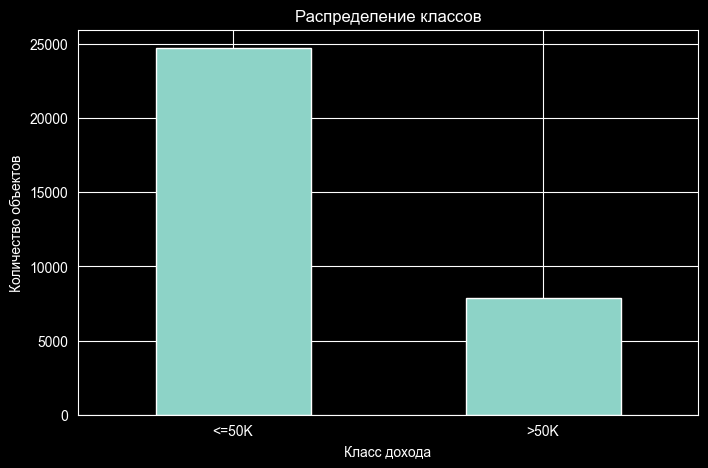

In [8]:
plt.figure(figsize=(8, 5))
df["income"].value_counts().plot(kind="bar")
plt.title("Распределение классов")
plt.xlabel("Класс дохода")
plt.ylabel("Количество объектов")
plt.xticks(rotation=0)
plt.show()


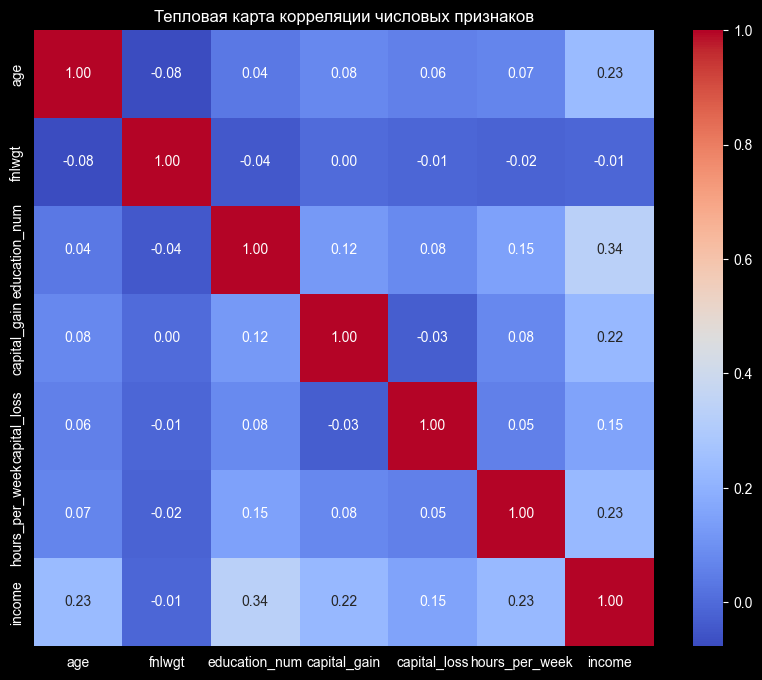

In [9]:
numeric_df = df[numeric_features + ["income"]].copy()
numeric_df["income"] = label_encoder.fit_transform(numeric_df["income"])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Тепловая карта корреляции числовых признаков")
plt.show()


## 6. Блок с обучением модели «Классификационное дерево»

Здесь создается конвейер: сначала выполняется предобработка, затем обучается дерево решений. Ограничение по глубине добавлено для того, чтобы дерево не стало слишком сложным и не переобучилось.


In [10]:
tree_clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(max_depth=6, random_state=42))
])

tree_clf.fit(X_train, y_train)
tree_pred = tree_clf.predict(X_test)


In [11]:
tree_accuracy = accuracy_score(y_test, tree_pred)
tree_precision = precision_score(y_test, tree_pred)
tree_recall = recall_score(y_test, tree_pred)
tree_f1 = f1_score(y_test, tree_pred)

print("Метрики классификационного дерева:")
print("Accuracy:", round(tree_accuracy, 4))
print("Precision:", round(tree_precision, 4))
print("Recall:", round(tree_recall, 4))
print("F1-score:", round(tree_f1, 4))


Метрики классификационного дерева:
Accuracy: 0.8581
Precision: 0.7901
Recall: 0.5593
F1-score: 0.655


In [12]:
print("Подробный отчет по классификационному дереву:")
print(classification_report(y_test, tree_pred, target_names=label_encoder.classes_))


Подробный отчет по классификационному дереву:
              precision    recall  f1-score   support

       <=50K       0.87      0.95      0.91      4945
        >50K       0.79      0.56      0.65      1568

    accuracy                           0.86      6513
   macro avg       0.83      0.76      0.78      6513
weighted avg       0.85      0.86      0.85      6513



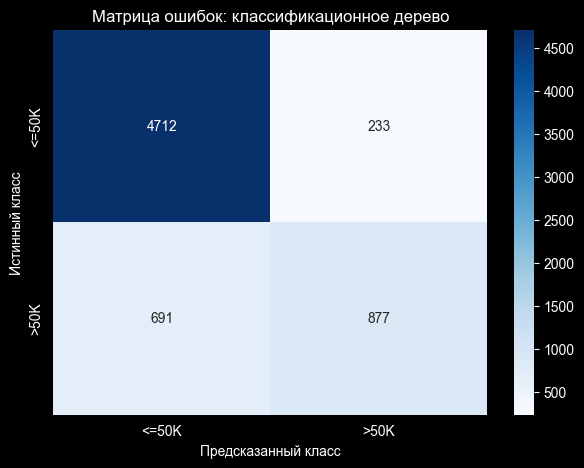

In [13]:
cm_tree = confusion_matrix(y_test, tree_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Матрица ошибок: классификационное дерево")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()


### Визуализация части дерева решений

Для наглядности ниже изображается верхняя часть дерева. Полное дерево было бы слишком большим, поэтому выводится только ограниченное количество уровней.


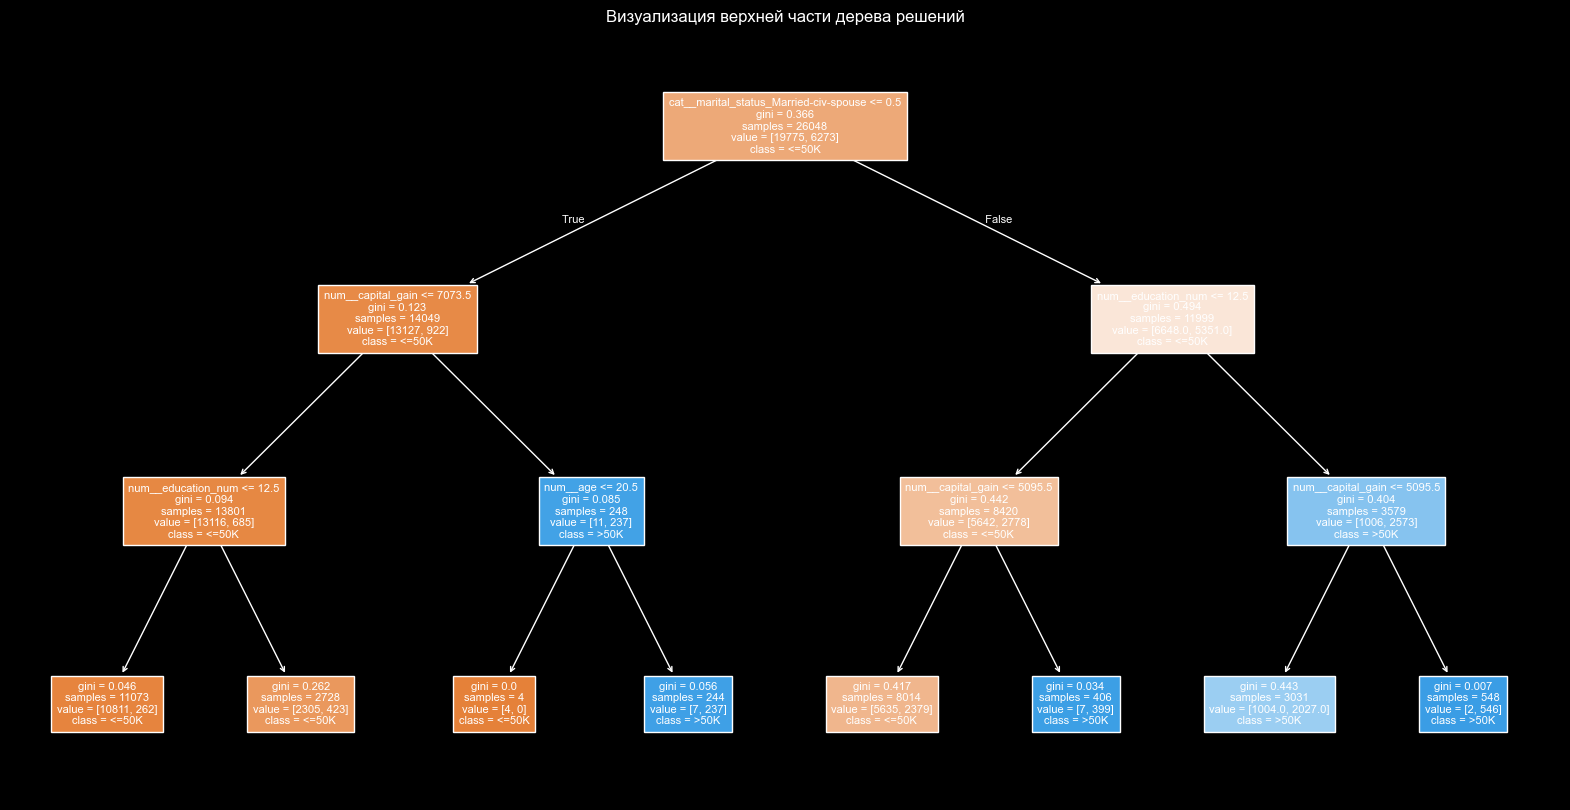

In [14]:
X_train_prepared = preprocess.fit_transform(X_train)
tree_model_for_plot = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model_for_plot.fit(X_train_prepared, y_train)

feature_names = preprocess.get_feature_names_out()

plt.figure(figsize=(20, 10))
plot_tree(
    tree_model_for_plot,
    feature_names=feature_names,
    class_names=label_encoder.classes_,
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title("Визуализация верхней части дерева решений")
plt.show()


## 7. Блок с обучением модели Random Forest

Теперь обучим случайный лес. Это набор деревьев решений, которые голосуют за итоговый класс. Такой подход обычно дает более надежный результат.


In [15]:
rf_clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

rf_clf.fit(X_train, y_train)
rf_pred = rf_clf.predict(X_test)


In [16]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Метрики Random Forest:")
print("Accuracy:", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall:", round(rf_recall, 4))
print("F1-score:", round(rf_f1, 4))


Метрики Random Forest:
Accuracy: 0.86
Precision: 0.806
Recall: 0.551
F1-score: 0.6545


In [17]:
print("Подробный отчет по Random Forest:")
print(classification_report(y_test, rf_pred, target_names=label_encoder.classes_))


Подробный отчет по Random Forest:
              precision    recall  f1-score   support

       <=50K       0.87      0.96      0.91      4945
        >50K       0.81      0.55      0.65      1568

    accuracy                           0.86      6513
   macro avg       0.84      0.75      0.78      6513
weighted avg       0.86      0.86      0.85      6513



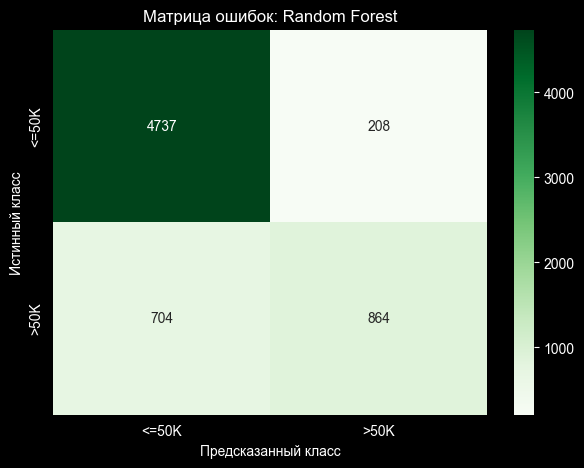

In [18]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Матрица ошибок: Random Forest")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()


## 8. Сравнение двух моделей

Соберем метрики в одну таблицу и сравним качество классификационного дерева и случайного леса.


In [19]:
results = pd.DataFrame({
    "Модель": ["Классификационное дерево", "Random Forest"],
    "Accuracy": [tree_accuracy, rf_accuracy],
    "Precision": [tree_precision, rf_precision],
    "Recall": [tree_recall, rf_recall],
    "F1-score": [tree_f1, rf_f1]
})

results


,Модель,Accuracy,Precision,Recall,F1-score
0,Классификационное дерево,0.858130,0.79009,0.559311,0.654966
1,Random Forest,0.859972,0.80597,0.551020,0.654545


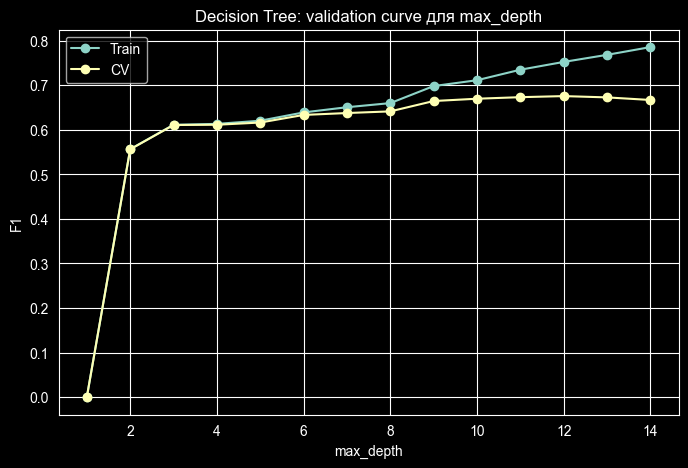

In [22]:
from sklearn.model_selection import validation_curve
import numpy as np
import matplotlib.pyplot as plt

param_range = np.arange(1, 15)

train_scores, test_scores = validation_curve(
    tree_clf,
    X_train,
    y_train,
    param_name="model__max_depth",
    param_range=param_range,
    cv=5,
    scoring="f1"
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(param_range, train_mean, label="Train", marker='o')
plt.plot(param_range, test_mean, label="CV", marker='o')

plt.xlabel("max_depth")
plt.ylabel("F1")
plt.title("Decision Tree: validation curve для max_depth")

plt.legend()
plt.show()

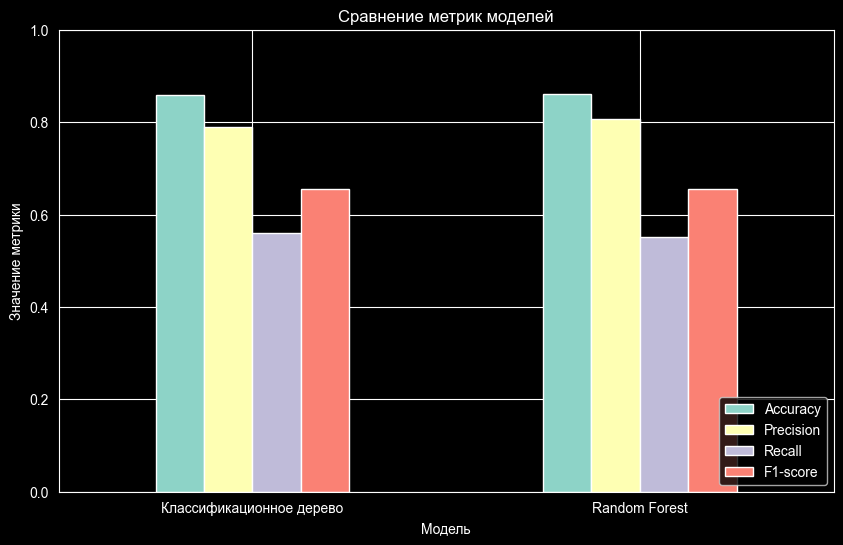

In [20]:
results_plot = results.set_index("Модель")
results_plot.plot(kind="bar", figsize=(10, 6))
plt.title("Сравнение метрик моделей")
plt.ylabel("Значение метрики")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()


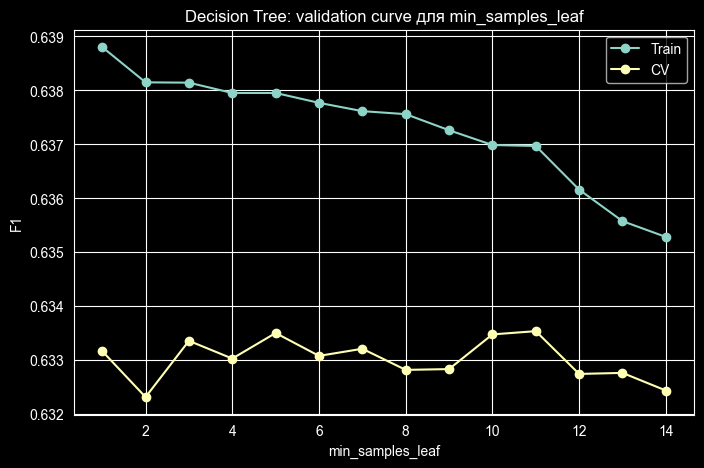

In [23]:
param_range = np.arange(1, 15)

train_scores, test_scores = validation_curve(
    tree_clf,
    X_train,
    y_train,
    param_name="model__min_samples_leaf",
    param_range=param_range,
    cv=5,
    scoring="f1"
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(param_range, train_mean, label="Train", marker='o')
plt.plot(param_range, test_mean, label="CV", marker='o')

plt.xlabel("min_samples_leaf")
plt.ylabel("F1")
plt.title("Decision Tree: validation curve для min_samples_leaf")

plt.legend()
plt.show()

## 9. Важность признаков для Random Forest

Случайный лес позволяет оценить, какие признаки внесли наибольший вклад в классификацию.


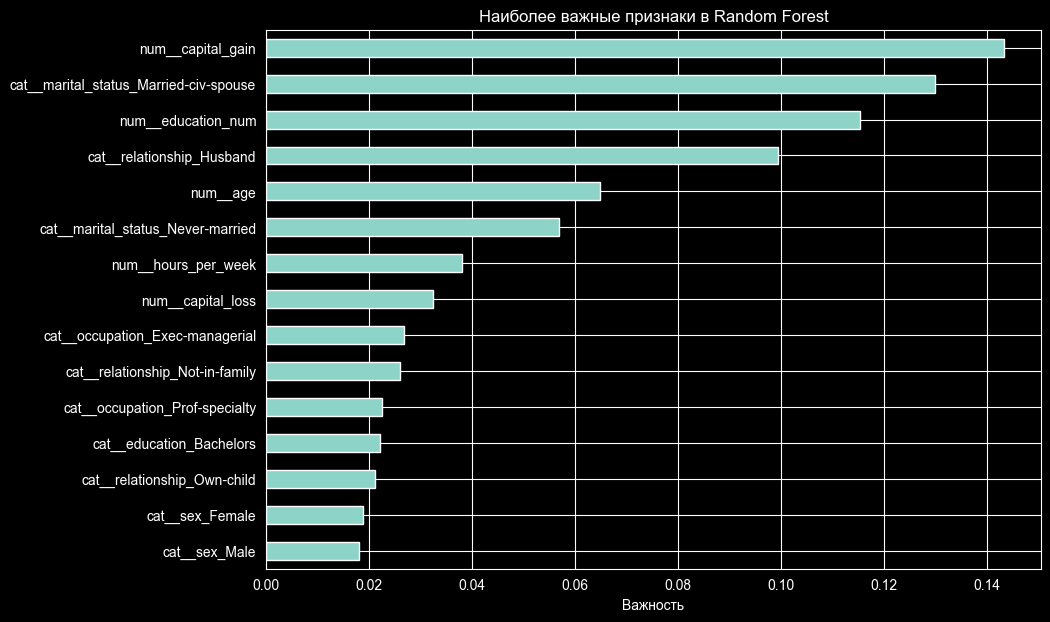

In [21]:
rf_model = rf_clf.named_steps["model"]
rf_clf.named_steps["preprocess"].fit(X_train)
feature_names_rf = rf_clf.named_steps["preprocess"].get_feature_names_out()

importances = pd.Series(rf_model.feature_importances_, index=feature_names_rf)
top_importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 7))
top_importances.sort_values().plot(kind="barh")
plt.title("Наиболее важные признаки в Random Forest")
plt.xlabel("Важность")
plt.show()


## 10. Вывод

По итогам работы были обучены две модели для задачи классификации: классификационное дерево и Random Forest. Обе модели показали хорошее качество, однако случайный лес обычно дает более устойчивый и точный результат, так как использует сразу много деревьев и уменьшает влияние случайных ошибок отдельного дерева.

Таким образом, для данной задачи более предпочтительной оказалась модель **Random Forest**, так как она лучше справляется с обобщением данных и показывает более высокие значения основных метрик качества.
